##  IMPA Tech - IMPA - Instituto de Matemática Pura e Aplicada

### Participantes: Natália e Heitor
  


## Bibliotecas necessárias

In [24]:
import pandas as pd
import matplotlib.pyplot as plt


## Carregando a base de dados 

In [25]:

url = "https://github.com/infogripe/Boletim_InfoGripe/raw/refs/heads/main/Dados/InfoGripe/casos_semanais_fx_etaria_virus_sem_filtro_febre.csv"

df = pd.read_csv(url, sep=";")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 181279 entries, 0 to 181278
Data columns (total 36 columns):
 #   Column                 Non-Null Count   Dtype
---  ------                 --------------   -----
 0   SG_UF_NOT              181279 non-null  int64
 1   fx_etaria              181279 non-null  str  
 2   SRAG                   181279 non-null  int64
 3   SARS2                  181279 non-null  int64
 4   VSR                    181279 non-null  int64
 5   FLU                    181279 non-null  int64
 6   FLU_A                  181279 non-null  int64
 7   FLU_AH1N1              181279 non-null  int64
 8   FLU_AH3N2              181279 non-null  int64
 9   FLU_ANSUBTPD           181279 non-null  int64
 10  FLU_ANSUBTPV           181279 non-null  int64
 11  FLU_AINC               181279 non-null  int64
 12  FLU_AOUT               181279 non-null  int64
 13  FLU_B                  181279 non-null  int64
 14  FLU_BVIC               181279 non-null  int64
 15  FLU_BYAM               18127

C:\Users\Lya\AppData\Local\Temp\ipykernel_26552\741302333.py:3: DtypeWarning: Columns (0: DS_UF_SIGLA) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url, sep=";")


In [26]:
df.head()

,SG_UF_NOT,fx_etaria,SRAG,SARS2,VSR,FLU,FLU_A,FLU_AH1N1,FLU_AH3N2,FLU_ANSUBTPD,...,PARA4,OUTROS,positivos,negativos,aguardando,DS_UF_SIGLA,epiyear,epiweek,Semana epidemiológica,Ano epidemiológico
0,0,< 2,1,0,0,0,0,0,0,0,...,0,0,0,1,0,BR,2009,16,16,2009
1,0,< 2,3,0,0,1,1,0,0,0,...,0,1,2,0,0,BR,2009,17,17,2009
2,0,< 2,1,0,0,0,0,0,0,0,...,0,0,0,1,0,BR,2009,18,18,2009
3,0,< 2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,BR,2009,19,19,2009
4,0,< 2,1,0,0,0,0,0,0,0,...,0,0,0,1,0,BR,2009,20,20,2009


## Analisando os casos de vsr (ignorando a faixa etária) de 2009 - 2026 

In [27]:
vsr = (
    df.groupby(
        ["DS_UF_SIGLA", "epiyear", "epiweek"]
    )["VSR"]
    .sum()
    .reset_index()
)

vsr.head()

,DS_UF_SIGLA,epiyear,epiweek,VSR
0,AC,2009,16,0
1,AC,2009,17,0
2,AC,2009,18,0
3,AC,2009,19,0
4,AC,2009,20,0


In [28]:
vsr.info()

<class 'pandas.DataFrame'>
RangeIndex: 25004 entries, 0 to 25003
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   DS_UF_SIGLA  25004 non-null  str  
 1   epiyear      25004 non-null  int64
 2   epiweek      25004 non-null  int64
 3   VSR          25004 non-null  int64
dtypes: int64(3), str(1)
memory usage: 833.4 KB


In [29]:
vsr[vsr["epiyear"] == 2009]

,DS_UF_SIGLA,epiyear,epiweek,VSR
0,AC,2009,16,0
1,AC,2009,17,0
2,AC,2009,18,0
3,AC,2009,19,0
4,AC,2009,20,0
...,...,...,...,...
24143,TO,2009,48,0
24144,TO,2009,49,0
24145,TO,2009,50,0
24146,TO,2009,51,0


In [30]:
vsr[vsr["epiyear"] == 2010]

,DS_UF_SIGLA,epiyear,epiweek,VSR
37,AC,2010,1,0
38,AC,2010,2,0
39,AC,2010,3,0
40,AC,2010,4,0
41,AC,2010,5,0
...,...,...,...,...
24195,TO,2010,48,0
24196,TO,2010,49,0
24197,TO,2010,50,0
24198,TO,2010,51,0


Note que a cada ano tem a semana 1, 2, ..., para facilitar nossa análise, adicionaremos uma nova coluna de forma que o número da semana seja crescente.

In [31]:
# ignorando os estados por enquanto
vsr_global = (
    vsr.groupby(["epiyear", "epiweek"])["VSR"]
       .sum()
       .reset_index()
)

vsr_global.head()

,epiyear,epiweek,VSR
0,2009,16,0
1,2009,17,0
2,2009,18,0
3,2009,19,0
4,2009,20,0


In [33]:
vsr_global["semana_global"] = range(1, len(vsr_global) + 1)

vsr_global

,epiyear,epiweek,VSR,semana_global
0,2009,16,0,1
1,2009,17,0,2
2,2009,18,0,3
3,2009,19,0,4
4,2009,20,0,5
...,...,...,...,...
888,2026,17,4900,889
889,2026,18,5140,890
890,2026,19,5296,891
891,2026,20,3476,892


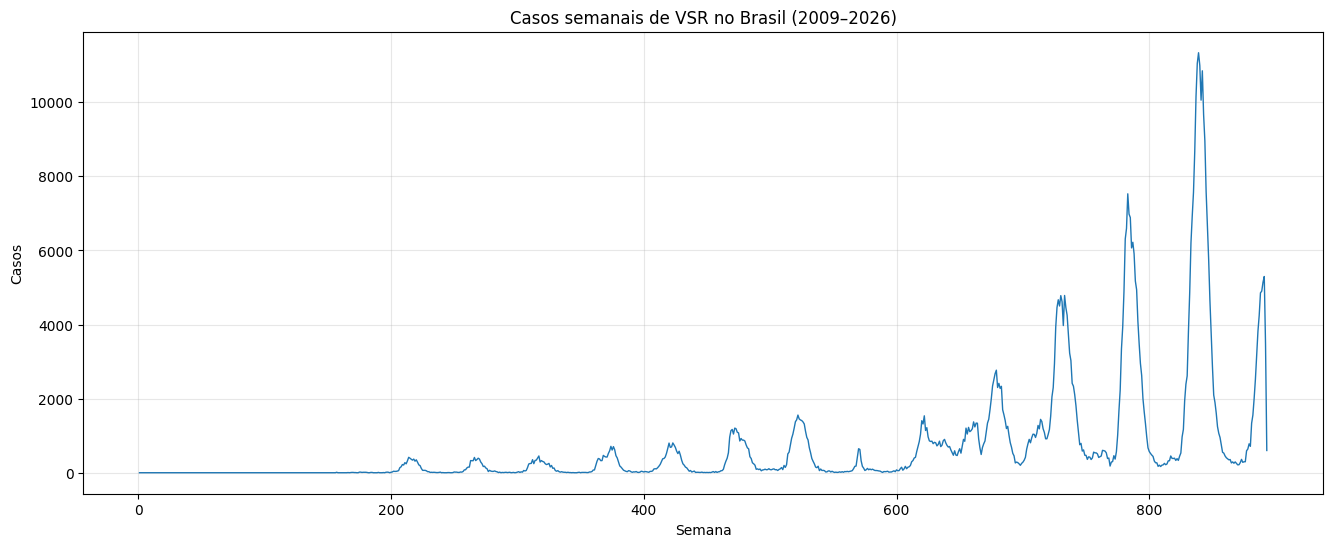

In [34]:
plt.figure(figsize=(16,6))

plt.plot(
    vsr_global["semana_global"],
    vsr_global["VSR"],
    linewidth=1
)

plt.title("Casos semanais de VSR no Brasil (2009–2026)")
plt.xlabel("Semana")
plt.ylabel("Casos")
plt.grid(alpha=0.3)

plt.show()